<a href="https://www.kaggle.com/code/lalit7881/llm-hallucination-detection-dataset-eda-100?scriptVersionId=319202765" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/llm-hallucination-benchmark-dataset/llm_hallucination_dataset_v1.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/llm-hallucination-benchmark-dataset/llm_hallucination_dataset_v1.csv")

In [3]:
df.head()

,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,correction_text,severity,domain_risk,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes
0,70b69889-3b46-4b1e-8f83-b95720bddbcd,2024-11-02,GPT-4o,gpt-4o-2024-11-20,PROMPT_00001,Who invented the telephone?,Multi-Hop,The telephone was invented by Nikola Tesla in ...,History,Question-Answering,...,The telephone was invented by Alexander Graham...,High,Low-Stakes,human_expert,0.73,RAG,True,PubMed,Extrinsic,NaN
1,e93f6574-d3a1-4459-9ccc-8615bc2b627f,2024-09-24,Mistral-Large,mistral-large-2411,PROMPT_00002,What is the boiling point of water at sea level?,Multi-Hop,Water boils at 100 degrees Celsius (212 degree...,Science,Question-Answering,...,NaN,NaN,Low-Stakes,human_expert,0.88,NaN,False,ArXiv,NaN,NaN
2,fc732394-9369-4811-8484-e07f69cb6fab,2025-01-29,Mistral-Large,mistral-large-2411,PROMPT_00003,What is the recommended first-line treatment f...,Ambiguous,The first-line pharmacological treatment for T...,Medicine,Question-Answering,...,Metformin is the recommended first-line pharma...,High,High-Stakes,human_expert,0.83,Self-Consistency,True,SEC-Filing,Extrinsic,NaN
3,2e488a3d-bfc4-4d1e-b59b-eeca571c9c27,2024-10-26,Llama-3.1-70B,llama-3.1-70b-instruct,PROMPT_00004,When was Apple Inc. founded?,Ambiguous,"Apple Inc. was founded on April 1, 1976, by St...",Finance,Question-Answering,...,NaN,NaN,Low-Stakes,human_crowd,0.86,CoT-Prompting,True,PubMed,NaN,NaN
4,eb1c2d1e-9fb6-46f0-9f65-0f36494db9dc,2024-11-07,Gemini-1.5-Pro,gemini-1.5-pro-002,PROMPT_00005,Is it legal to record a phone call without con...,Direct-Factual,"In California, you can legally record a phone ...",Law,Fact-Verification,...,California is an all-party consent state; all ...,High,High-Stakes,human_expert,0.95,Structured-Prompt,True,Snopes,Extrinsic,NaN


In [4]:
df.tail()

,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,correction_text,severity,domain_risk,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes
195,dc1ddb29-e3d9-4651-a570-c7439d420f95,2025-04-03,GPT-4o,gpt-4o-2024-11-20,PROMPT_00196,When did the Soviet Union collapse?,Ambiguous,The Soviet Union officially dissolved on Decem...,History,Dialogue,...,"Gorbachev resigned on December 25, 1991, but t...",Low,Low-Stakes,llm_judge_gpt4o,0.81,NaN,False,Wikipedia,Intrinsic,NaN
196,7f2a8697-2deb-4a69-8a08-3802e53886f8,2025-02-26,Gemini-1.5-Pro,gemini-1.5-pro-002,PROMPT_00197,Summarize what a hedge fund does.,Multi-Hop,A hedge fund is a pooled investment vehicle th...,Finance,Summarization,...,Not all hedge funds are required to register w...,Medium,High-Stakes,human_crowd,0.97,Self-Consistency,True,Human-Expert,Extrinsic,NaN
197,c59849f3-99b3-4646-b8c4-9a7904e24e3b,2024-09-05,Mistral-Large,mistral-large-2411,PROMPT_00198,Can you explain what an API is?,Ambiguous,An API (Application Programming Interface) is ...,Technology,Dialogue,...,NaN,NaN,Low-Stakes,llm_judge_gpt4o,0.80,NaN,False,Snopes,NaN,NaN
198,a04df3dd-4a1f-4ef8-8d58-04ab3685903d,2024-11-17,GPT-4o,gpt-4o-2024-11-20,PROMPT_00199,Does the MMR vaccine cause autism?,Direct-Factual,No. The claim that the MMR vaccine causes auti...,Medicine,Fact-Verification,...,NaN,NaN,High-Stakes,human_crowd,0.95,CoT-Prompting,True,Human-Expert,NaN,NaN
199,6067be34-d199-4995-a770-cc3501f96725,2025-01-31,GPT-4o,gpt-4o-2024-11-20,PROMPT_00200,What is the chemical formula for table salt?,Long-Context,The chemical formula for table salt is NaCl (s...,General,Question-Answering,...,NaN,NaN,Low-Stakes,llm_judge_gpt4o,0.82,Self-Consistency,True,SEC-Filing,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               200 non-null    object 
 1   created_date            200 non-null    object 
 2   model_name              200 non-null    object 
 3   model_version           200 non-null    object 
 4   prompt_id               200 non-null    object 
 5   prompt_text             200 non-null    object 
 6   prompt_type             200 non-null    object 
 7   response_text           200 non-null    object 
 8   domain                  200 non-null    object 
 9   task_type               200 non-null    object 
 10  language                200 non-null    object 
 11  hallucination_label     200 non-null    int64  
 12  hallucination_type      69 non-null     object 
 13  hallucination_span      69 non-null     object 
 14  correct_information     69 non-null     ob

In [6]:
df.describe()

,hallucination_label,annotation_confidence,notes
count,200.000000,200.000000,0.0
mean,0.345000,0.880650,NaN
std,0.476561,0.063879,NaN
min,0.000000,0.730000,NaN
25%,0.000000,0.830000,NaN
50%,0.000000,0.880000,NaN
75%,1.000000,0.940000,NaN
max,1.000000,0.990000,NaN


In [7]:
df.isnull().sum()

record_id                   0
created_date                0
model_name                  0
model_version               0
prompt_id                   0
prompt_text                 0
prompt_type                 0
response_text               0
domain                      0
task_type                   0
language                    0
hallucination_label         0
hallucination_type        131
hallucination_span        131
correct_information       131
correction_text           131
severity                  131
domain_risk                 0
annotator_type              0
annotation_confidence       0
mitigation_strategy        39
mitigation_applied          0
verified_source             0
intrinsic_or_extrinsic    131
notes                     200
dtype: int64

In [8]:
df.isnull()

,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,correction_text,severity,domain_risk,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,True,False,False,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
197,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,True,False,False,True,True
198,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,True,True


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['record_id', 'created_date', 'model_name', 'model_version', 'prompt_id',
       'prompt_text', 'prompt_type', 'response_text', 'domain', 'task_type',
       'language', 'hallucination_label', 'hallucination_type',
       'hallucination_span', 'correct_information', 'correction_text',
       'severity', 'domain_risk', 'annotator_type', 'annotation_confidence',
       'mitigation_strategy', 'mitigation_applied', 'verified_source',
       'intrinsic_or_extrinsic', 'notes'],
      dtype='object')

In [11]:
df.nunique()

record_id                 200
created_date              135
model_name                  5
model_version               5
prompt_id                 200
prompt_text                53
prompt_type                 5
response_text              53
domain                      8
task_type                   6
language                    7
hallucination_label         2
hallucination_type          7
hallucination_span         18
correct_information        18
correction_text            18
severity                    3
domain_risk                 3
annotator_type              4
annotation_confidence      27
mitigation_strategy         4
mitigation_applied          2
verified_source             8
intrinsic_or_extrinsic      2
notes                       0
dtype: int64

In [12]:
df.dtypes

record_id                  object
created_date               object
model_name                 object
model_version              object
prompt_id                  object
prompt_text                object
prompt_type                object
response_text              object
domain                     object
task_type                  object
language                   object
hallucination_label         int64
hallucination_type         object
hallucination_span         object
correct_information        object
correction_text            object
severity                   object
domain_risk                object
annotator_type             object
annotation_confidence     float64
mitigation_strategy        object
mitigation_applied           bool
verified_source            object
intrinsic_or_extrinsic     object
notes                     float64
dtype: object

In [13]:
df.shape

(200, 25)

## EDA

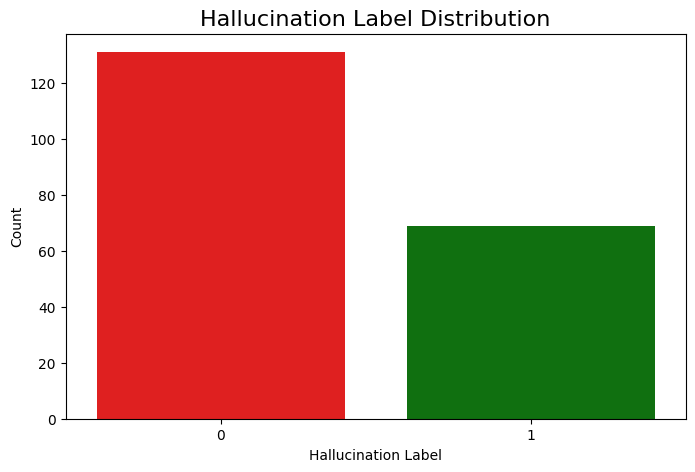

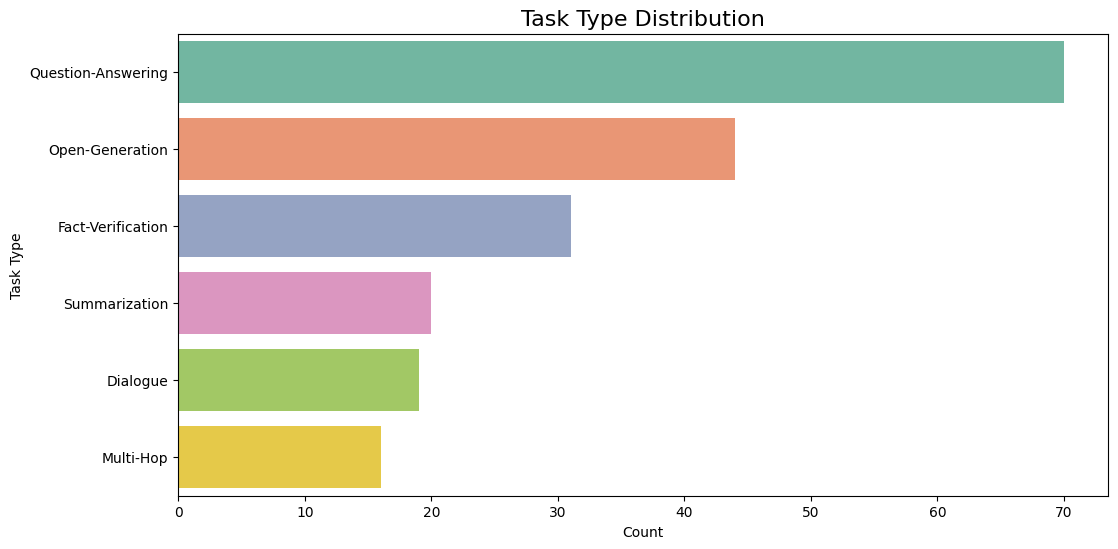

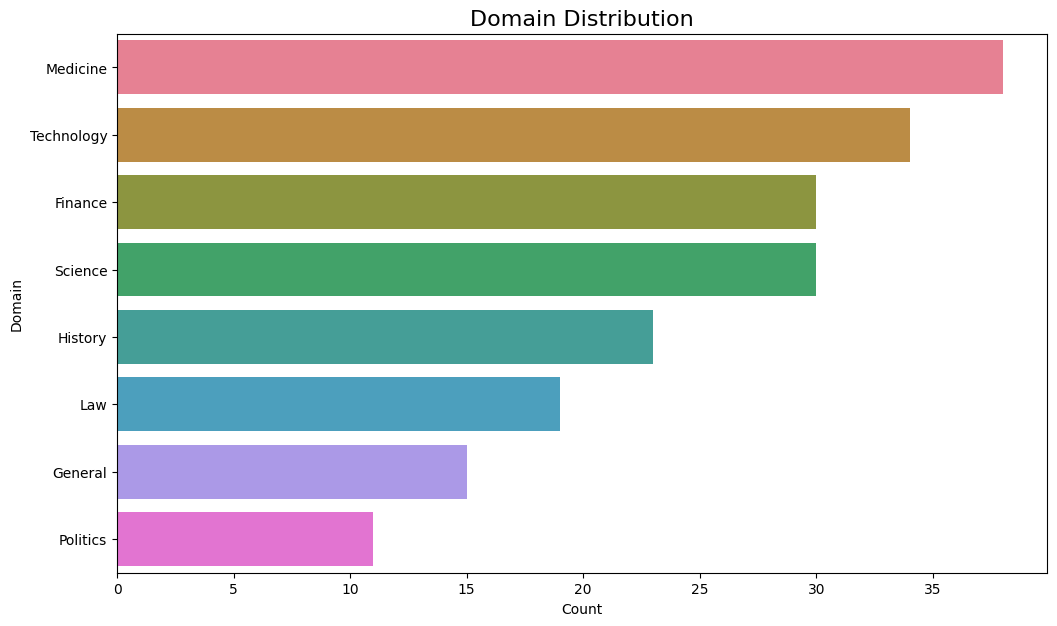

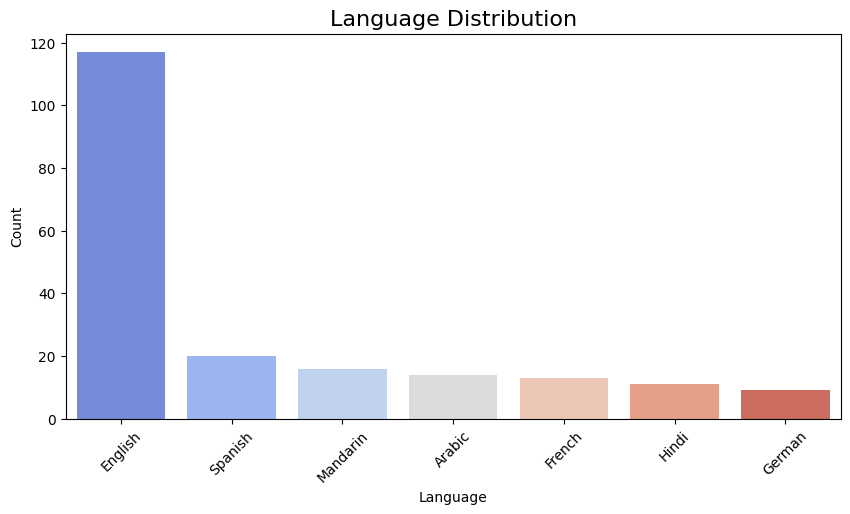

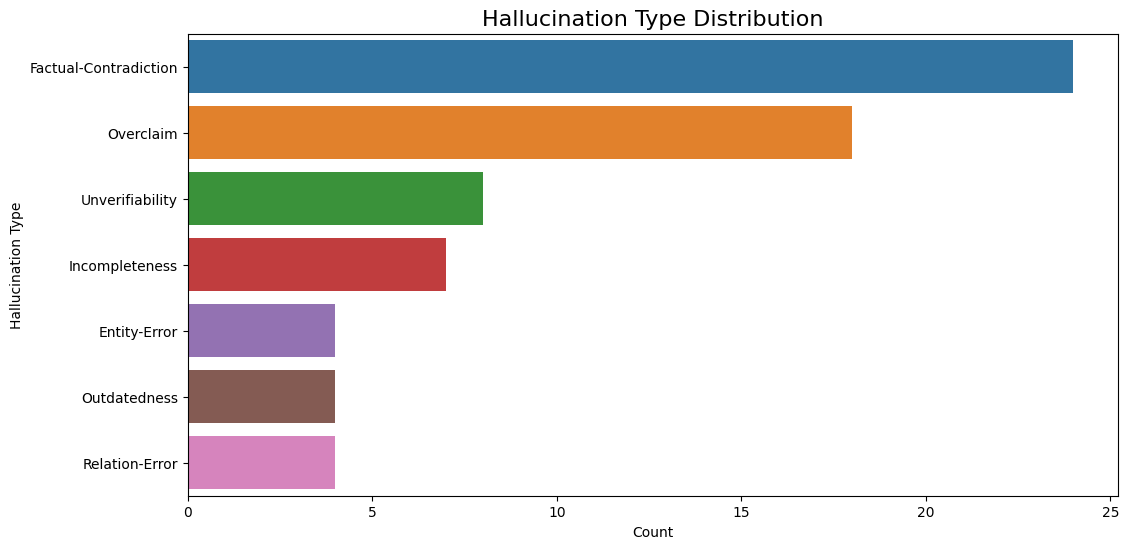

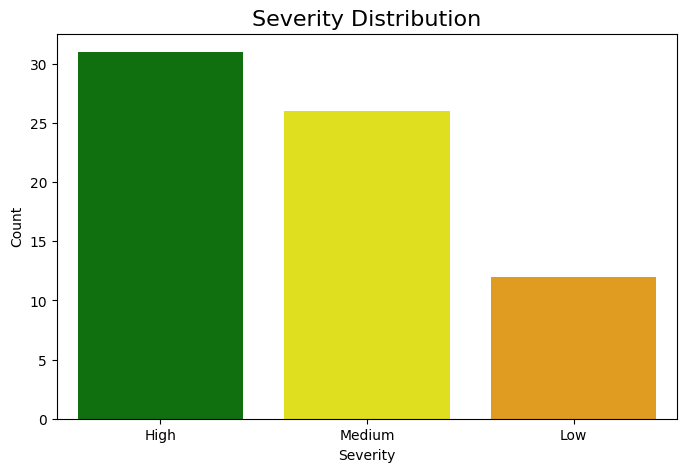

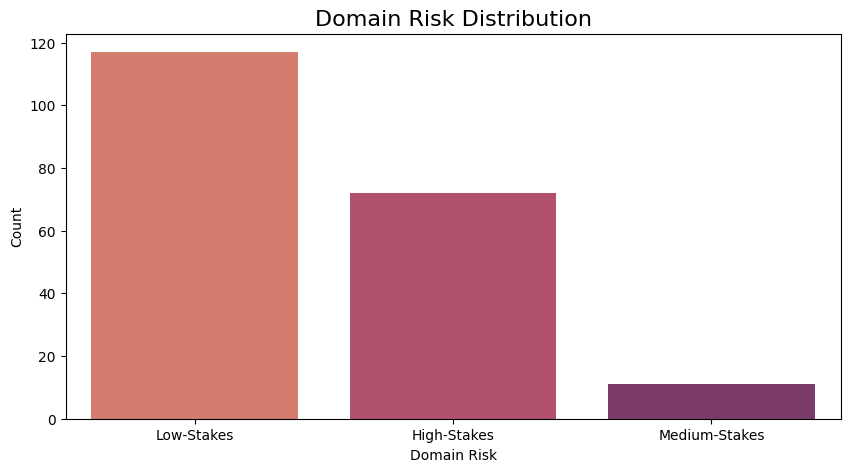

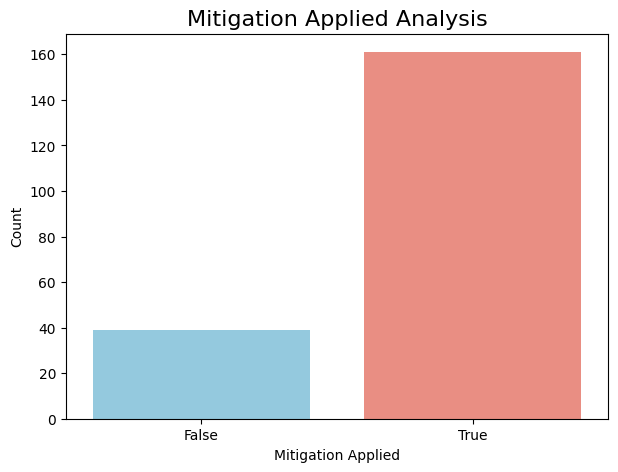

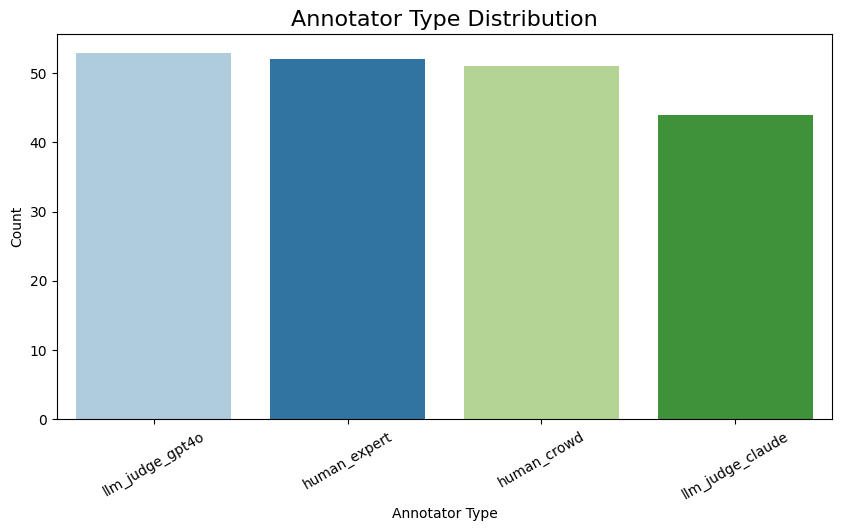

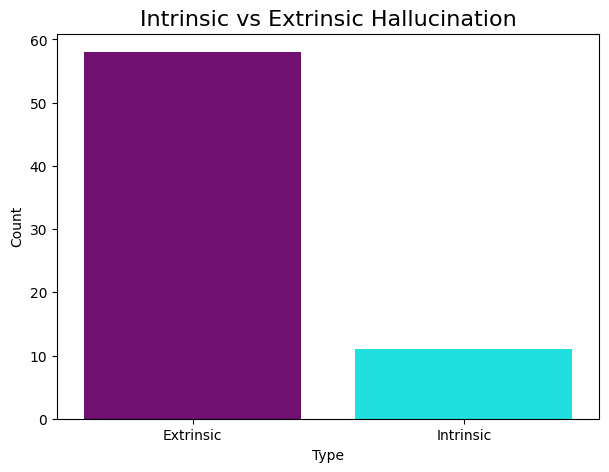

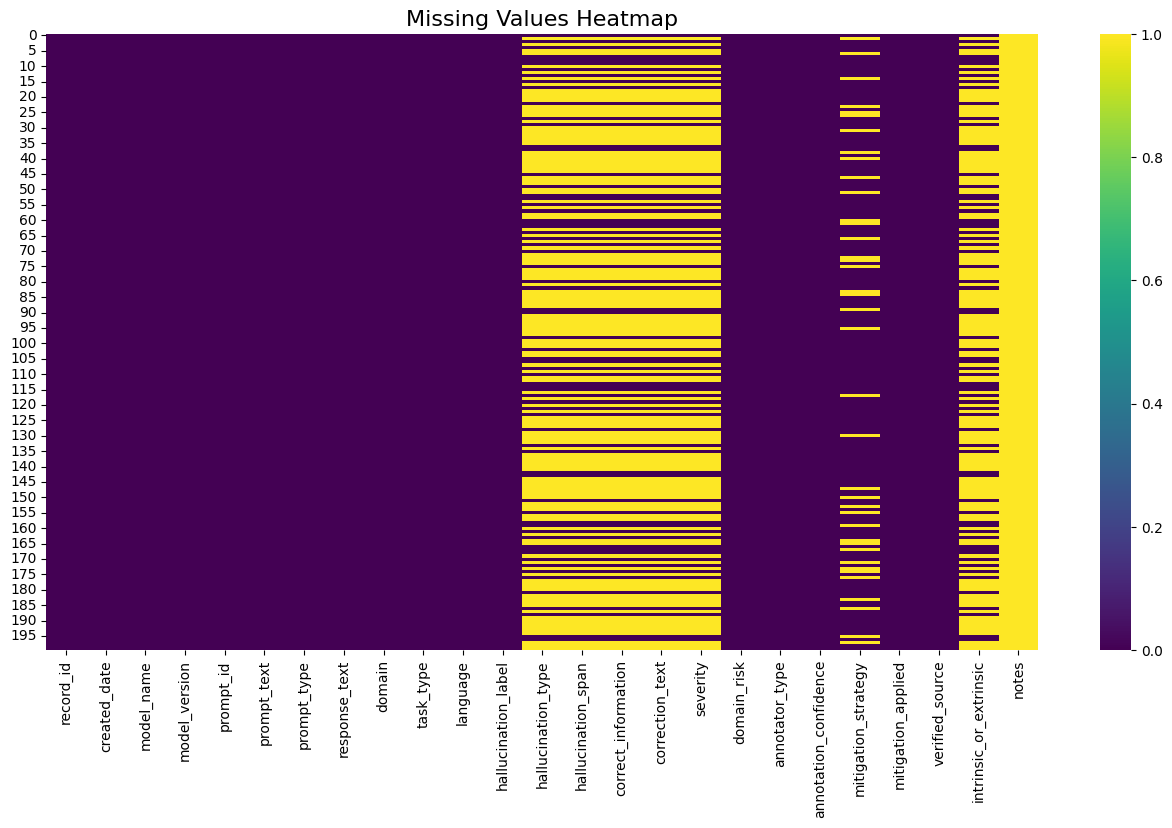

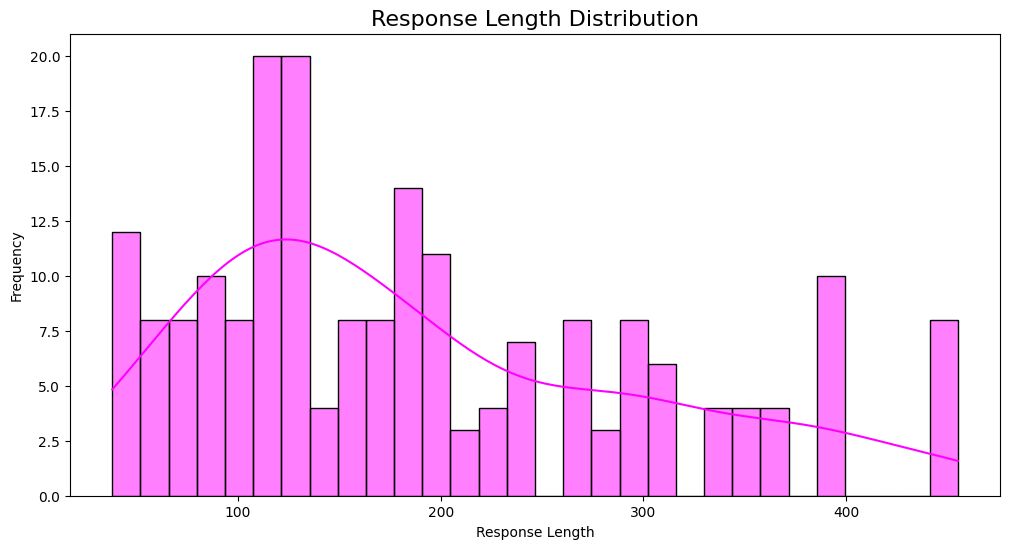

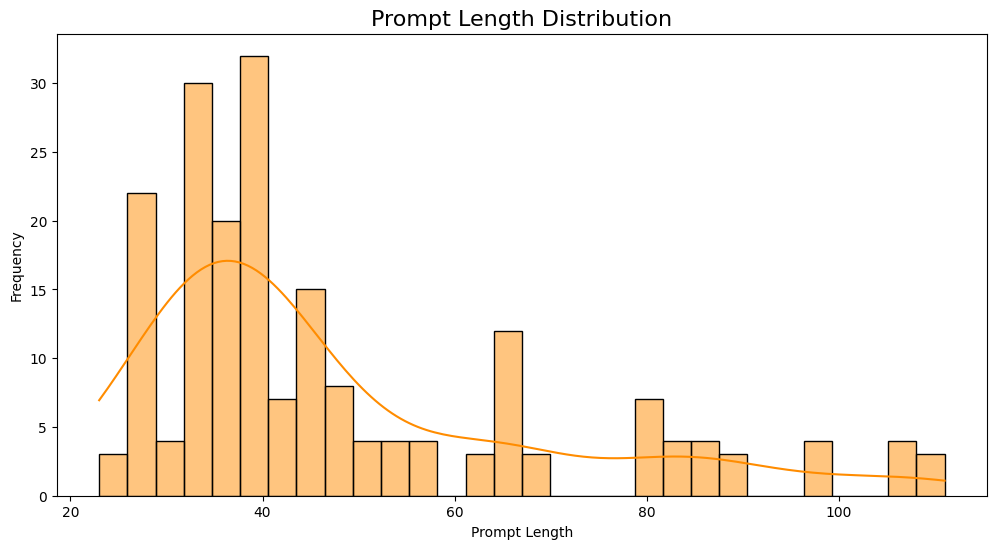

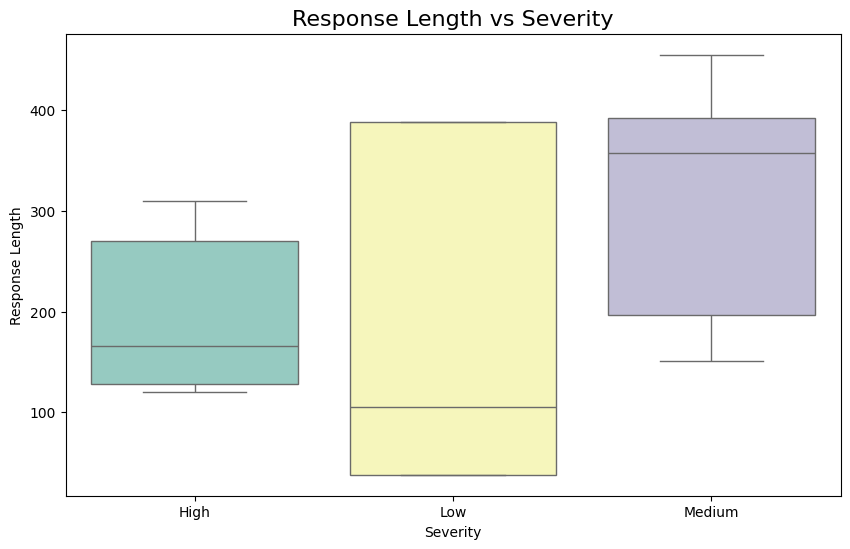

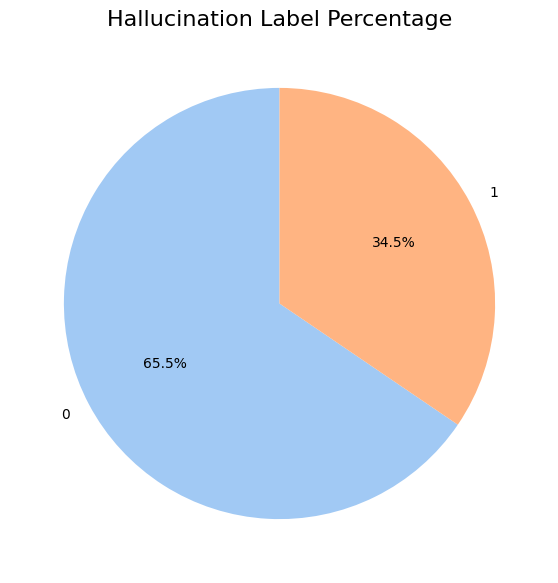

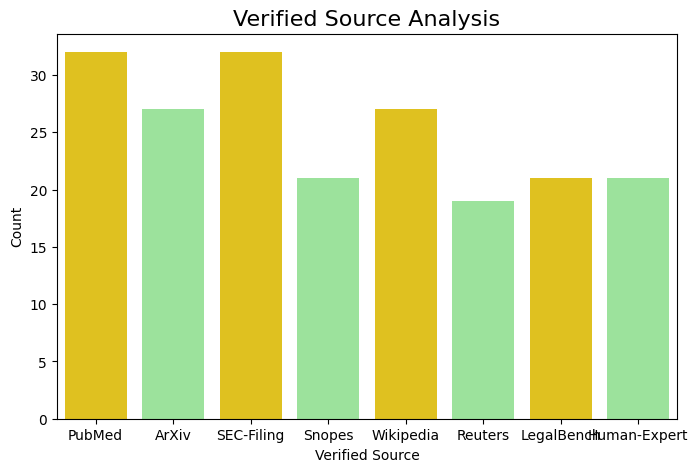

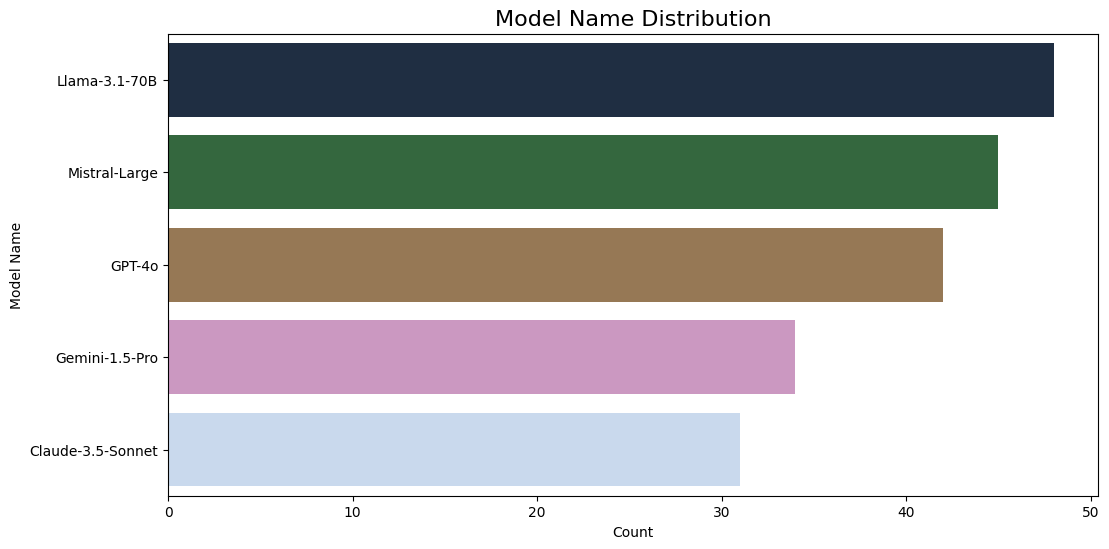

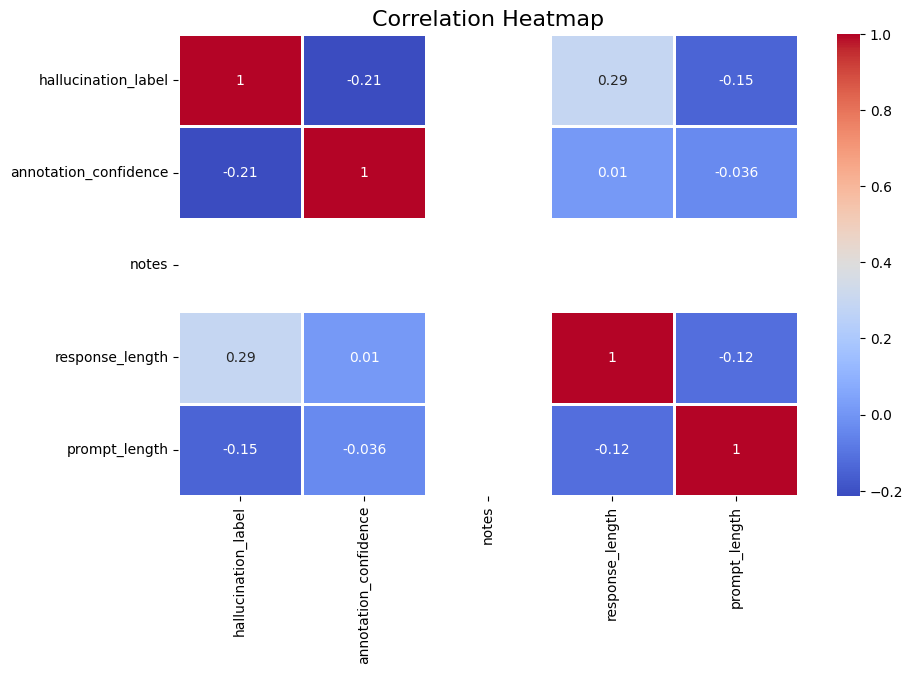

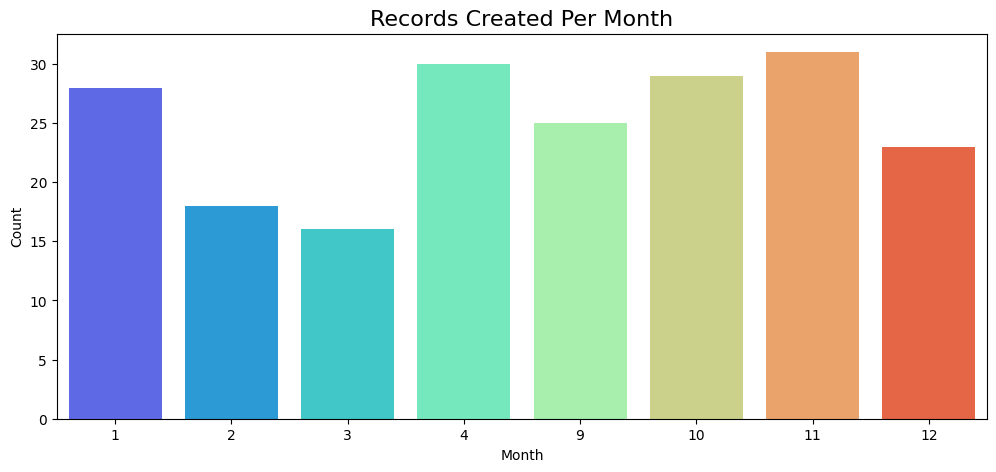

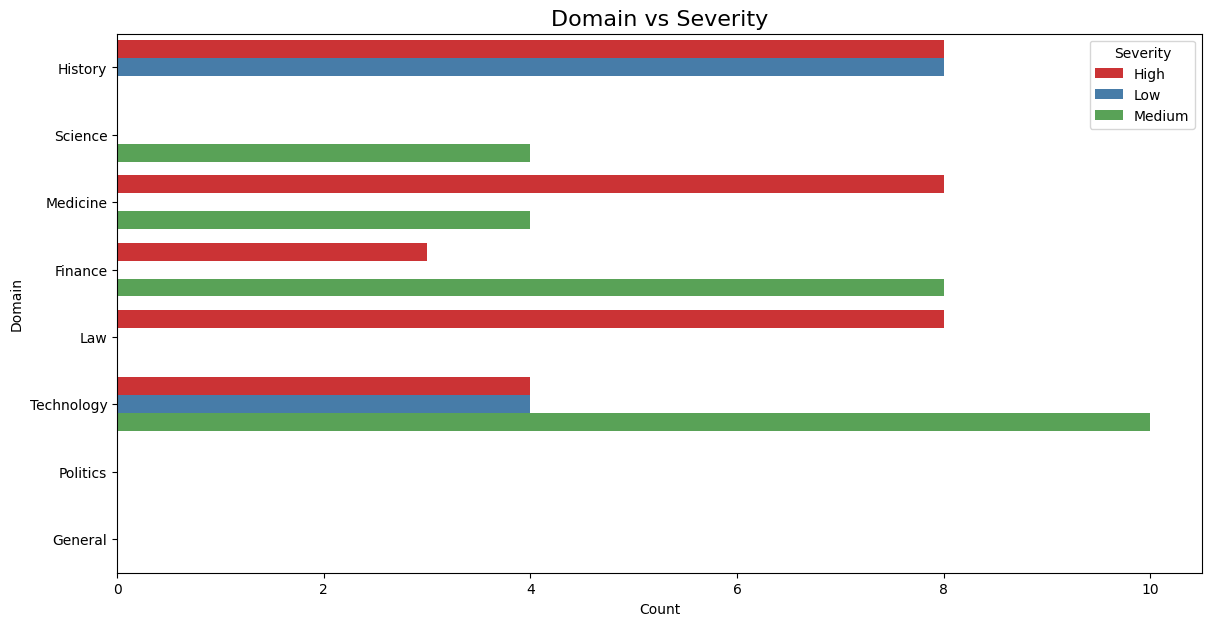

All Visualizations Completed Successfully!


In [14]:
# ============================================================
# 1. HALLUCINATION LABEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

colors = ['red', 'green', 'blue', 'orange']

sns.countplot(
    x='hallucination_label',
    data=df,
    palette=colors
)

plt.title("Hallucination Label Distribution", fontsize=16)
plt.xlabel("Hallucination Label")
plt.ylabel("Count")

plt.show()

# ============================================================
# 2. TASK TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

task_colors = sns.color_palette("Set2", len(df['task_type'].dropna().unique()))

sns.countplot(
    y='task_type',
    data=df,
    palette=task_colors,
    order=df['task_type'].value_counts().index
)

plt.title("Task Type Distribution", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Task Type")

plt.show()

# ============================================================
# 3. DOMAIN DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,7))

domain_colors = sns.color_palette("husl", len(df['domain'].dropna().unique()))

sns.countplot(
    y='domain',
    data=df,
    palette=domain_colors,
    order=df['domain'].value_counts().index
)

plt.title("Domain Distribution", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Domain")

plt.show()

# ============================================================
# 4. LANGUAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

lang_colors = sns.color_palette("coolwarm", len(df['language'].dropna().unique()))

sns.countplot(
    x='language',
    data=df,
    palette=lang_colors,
    order=df['language'].value_counts().index
)

plt.title("Language Distribution", fontsize=16)
plt.xlabel("Language")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 5. HALLUCINATION TYPE ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

hall_colors = sns.color_palette("tab10", len(df['hallucination_type'].dropna().unique()))

sns.countplot(
    y='hallucination_type',
    data=df,
    palette=hall_colors,
    order=df['hallucination_type'].value_counts().index
)

plt.title("Hallucination Type Distribution", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Hallucination Type")

plt.show()

# ============================================================
# 6. SEVERITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

severity_colors = ['green', 'yellow', 'orange', 'red']

sns.countplot(
    x='severity',
    data=df,
    palette=severity_colors,
    order=df['severity'].value_counts().index
)

plt.title("Severity Distribution", fontsize=16)
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

# ============================================================
# 7. DOMAIN RISK ANALYSIS
# ============================================================

plt.figure(figsize=(10,5))

risk_colors = sns.color_palette("flare", len(df['domain_risk'].dropna().unique()))

sns.countplot(
    x='domain_risk',
    data=df,
    palette=risk_colors,
    order=df['domain_risk'].value_counts().index
)

plt.title("Domain Risk Distribution", fontsize=16)
plt.xlabel("Domain Risk")
plt.ylabel("Count")

plt.show()

# ============================================================
# 8. MITIGATION APPLIED ANALYSIS
# ============================================================

plt.figure(figsize=(7,5))

mitigation_colors = ['skyblue', 'salmon']

sns.countplot(
    x='mitigation_applied',
    data=df,
    palette=mitigation_colors
)

plt.title("Mitigation Applied Analysis", fontsize=16)
plt.xlabel("Mitigation Applied")
plt.ylabel("Count")

plt.show()

# ============================================================
# 9. ANNOTATOR TYPE ANALYSIS
# ============================================================

plt.figure(figsize=(10,5))

annotator_colors = sns.color_palette("Paired", len(df['annotator_type'].dropna().unique()))

sns.countplot(
    x='annotator_type',
    data=df,
    palette=annotator_colors,
    order=df['annotator_type'].value_counts().index
)

plt.title("Annotator Type Distribution", fontsize=16)
plt.xlabel("Annotator Type")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

# ============================================================
# 10. INTRINSIC VS EXTRINSIC HALLUCINATION
# ============================================================

plt.figure(figsize=(7,5))

intrinsic_colors = ['purple', 'cyan']

sns.countplot(
    x='intrinsic_or_extrinsic',
    data=df,
    palette=intrinsic_colors
)

plt.title("Intrinsic vs Extrinsic Hallucination", fontsize=16)
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

# ============================================================
# 11. HEATMAP OF MISSING VALUES
# ============================================================

plt.figure(figsize=(16,8))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='viridis'
)

plt.title("Missing Values Heatmap", fontsize=16)

plt.show()

# ============================================================
# 12. RESPONSE LENGTH DISTRIBUTION
# ============================================================

# Create response length feature
df['response_length'] = df['response_text'].astype(str).apply(len)

plt.figure(figsize=(12,6))

sns.histplot(
    df['response_length'],
    bins=30,
    kde=True,
    color='magenta'
)

plt.title("Response Length Distribution", fontsize=16)
plt.xlabel("Response Length")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# 13. PROMPT LENGTH DISTRIBUTION
# ============================================================

# Create prompt length feature
df['prompt_length'] = df['prompt_text'].astype(str).apply(len)

plt.figure(figsize=(12,6))

sns.histplot(
    df['prompt_length'],
    bins=30,
    kde=True,
    color='darkorange'
)

plt.title("Prompt Length Distribution", fontsize=16)
plt.xlabel("Prompt Length")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# 14. BOXPLOT - RESPONSE LENGTH VS SEVERITY
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='severity',
    y='response_length',
    data=df,
    palette='Set3'
)

plt.title("Response Length vs Severity", fontsize=16)
plt.xlabel("Severity")
plt.ylabel("Response Length")

plt.show()

# ============================================================
# 15. PIE CHART - HALLUCINATION LABEL
# ============================================================

hall_counts = df['hallucination_label'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    hall_counts,
    labels=hall_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)

plt.title("Hallucination Label Percentage", fontsize=16)

plt.show()

# ============================================================
# 16. COUNT OF VERIFIED SOURCES
# ============================================================

plt.figure(figsize=(8,5))

verified_colors = ['gold', 'lightgreen']

sns.countplot(
    x='verified_source',
    data=df,
    palette=verified_colors
)

plt.title("Verified Source Analysis", fontsize=16)
plt.xlabel("Verified Source")
plt.ylabel("Count")

plt.show()

# ============================================================
# 17. TOP MODEL NAMES
# ============================================================

plt.figure(figsize=(12,6))

model_colors = sns.color_palette("cubehelix", len(df['model_name'].dropna().unique()))

sns.countplot(
    y='model_name',
    data=df,
    palette=model_colors,
    order=df['model_name'].value_counts().index
)

plt.title("Model Name Distribution", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Model Name")

plt.show()

# ============================================================
# 18. CORRELATION HEATMAP
# ============================================================

# Select numerical columns
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

# ============================================================
# 19. TIME-BASED ANALYSIS
# ============================================================

# Convert created_date to datetime
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

# Extract month
df['month'] = df['created_date'].dt.month

plt.figure(figsize=(12,5))

sns.countplot(
    x='month',
    data=df,
    palette='rainbow'
)

plt.title("Records Created Per Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Count")

plt.show()

# ============================================================
# 20. DOMAIN VS SEVERITY
# ============================================================

plt.figure(figsize=(14,7))

sns.countplot(
    y='domain',
    hue='severity',
    data=df,
    palette='Set1'
)

plt.title("Domain vs Severity", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Domain")

plt.legend(title='Severity')

plt.show()

# ============================================================
# END OF VISUALIZATION
# ============================================================

print("All Visualizations Completed Successfully!")

## Feature engineering

Dataset Shape : (200, 28)

Missing Values Before Cleaning:

record_id                   0
created_date                0
model_name                  0
model_version               0
prompt_id                   0
prompt_text                 0
prompt_type                 0
response_text               0
domain                      0
task_type                   0
language                    0
hallucination_label         0
hallucination_type        131
hallucination_span        131
correct_information       131
correction_text           131
severity                  131
domain_risk                 0
annotator_type              0
annotation_confidence       0
mitigation_strategy        39
mitigation_applied          0
verified_source             0
intrinsic_or_extrinsic    131
notes                     200
response_length             0
prompt_length               0
month                       0
dtype: int64

Categorical Columns : 20
Numerical Columns : 8

Remaining NaN in X_train : 0
Remaining

<Figure size 1200x800 with 0 Axes>

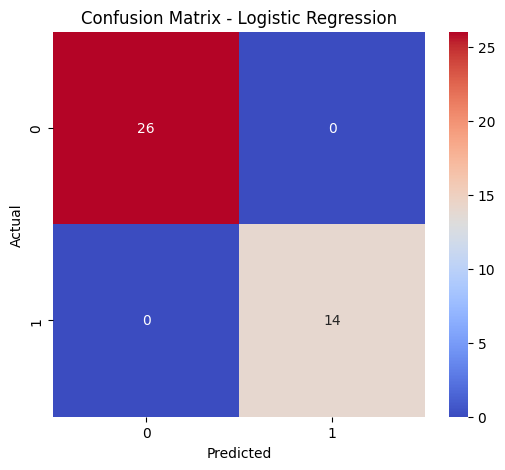


MODEL : Decision Tree

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



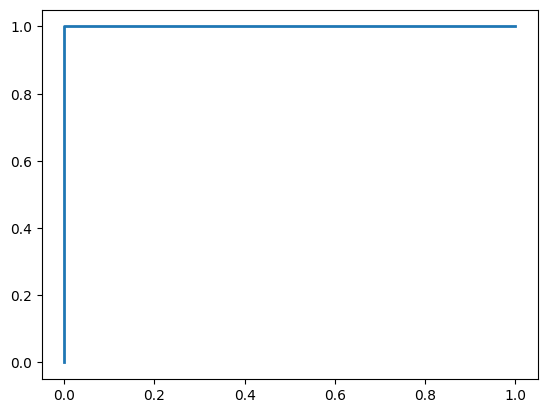

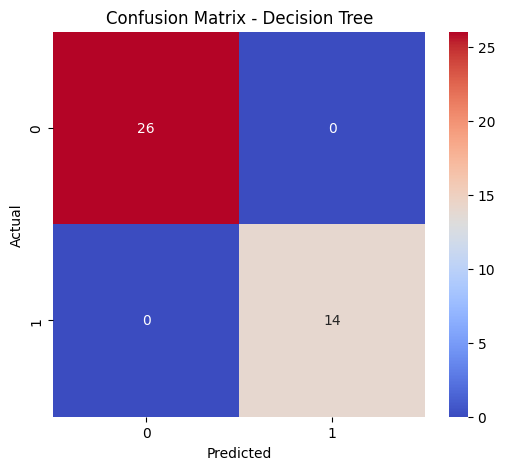


MODEL : Random Forest

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



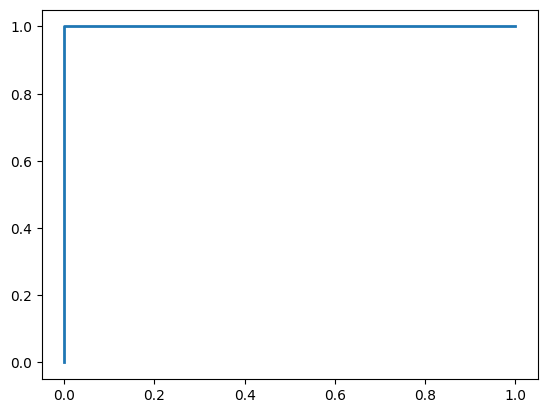

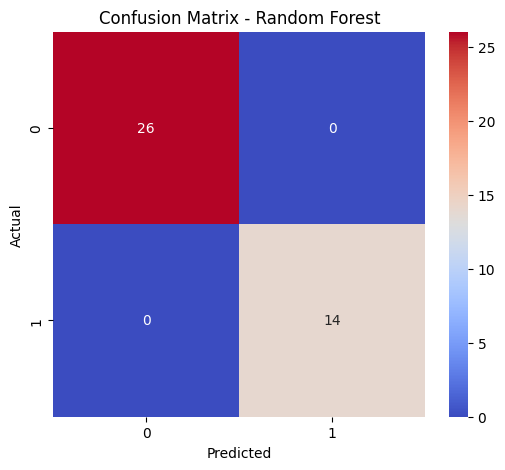


MODEL : Gradient Boosting

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



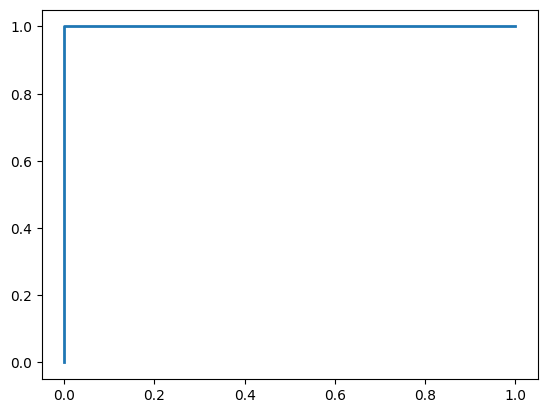

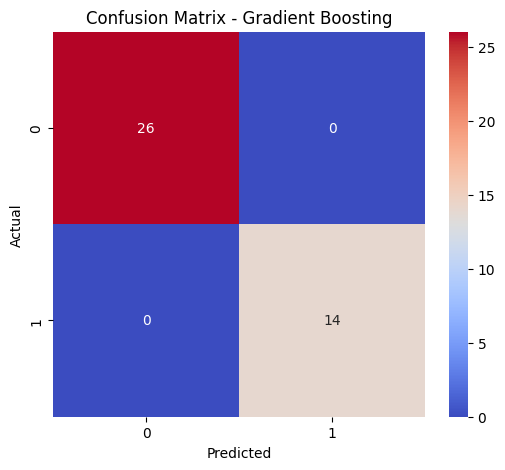


MODEL : Naive Bayes

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



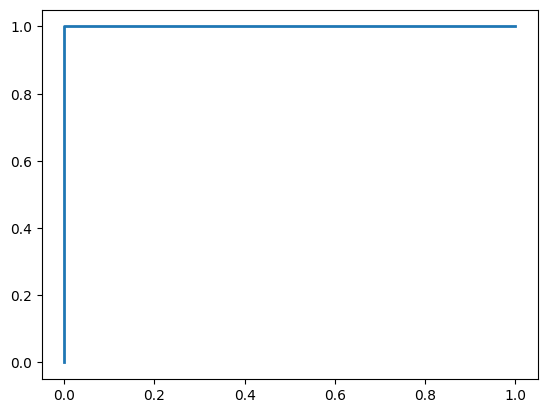

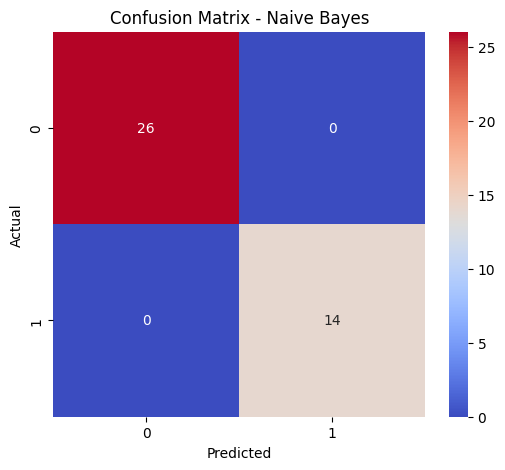


MODEL : KNN

Accuracy : 0.725
Precision : 0.8068
Recall : 0.725
F1 Score : 0.66

Classification Report:

              precision    recall  f1-score   support

           0       0.70      1.00      0.83        26
           1       1.00      0.21      0.35        14

    accuracy                           0.72        40
   macro avg       0.85      0.61      0.59        40
weighted avg       0.81      0.72      0.66        40



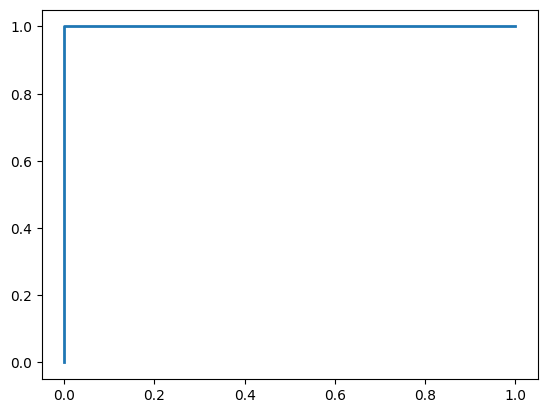

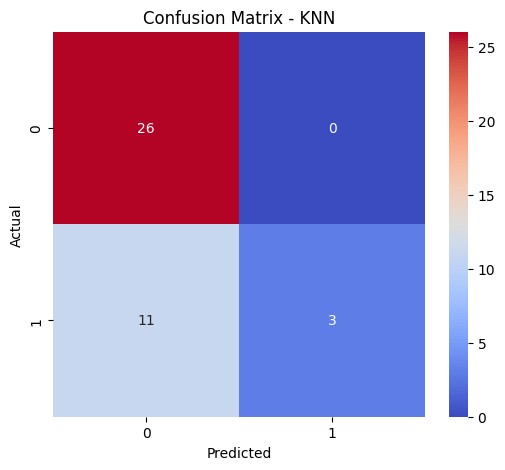


MODEL : SVM

Accuracy : 0.65
Precision : 0.4225
Recall : 0.65
F1 Score : 0.5121

Classification Report:

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        26
           1       0.00      0.00      0.00        14

    accuracy                           0.65        40
   macro avg       0.33      0.50      0.39        40
weighted avg       0.42      0.65      0.51        40



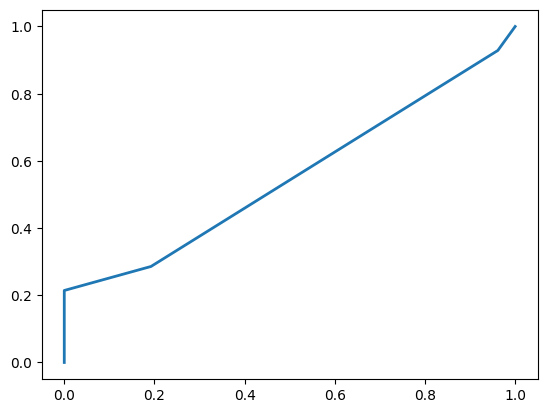

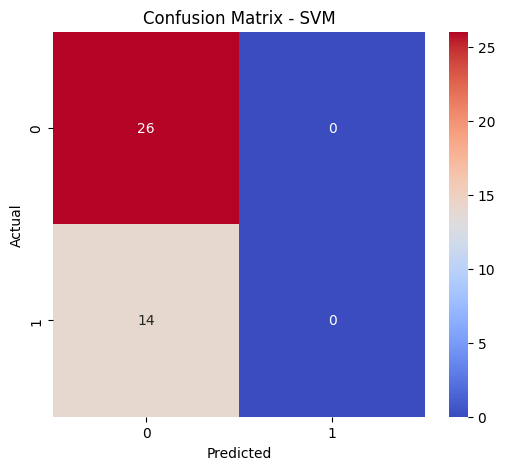

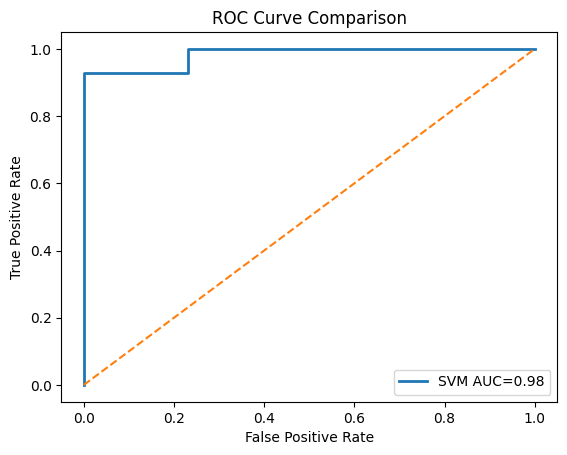


FINAL MODEL COMPARISON

                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0  Logistic Regression     1.000   1.000000   1.000  1.000000  1.000000
1        Decision Tree     1.000   1.000000   1.000  1.000000  1.000000
2        Random Forest     1.000   1.000000   1.000  1.000000  1.000000
3    Gradient Boosting     1.000   1.000000   1.000  1.000000  1.000000
4          Naive Bayes     1.000   1.000000   1.000  1.000000  1.000000
5                  KNN     0.725   0.806757   0.725  0.660037  0.552198
6                  SVM     0.650   0.422500   0.650  0.512121  0.983516


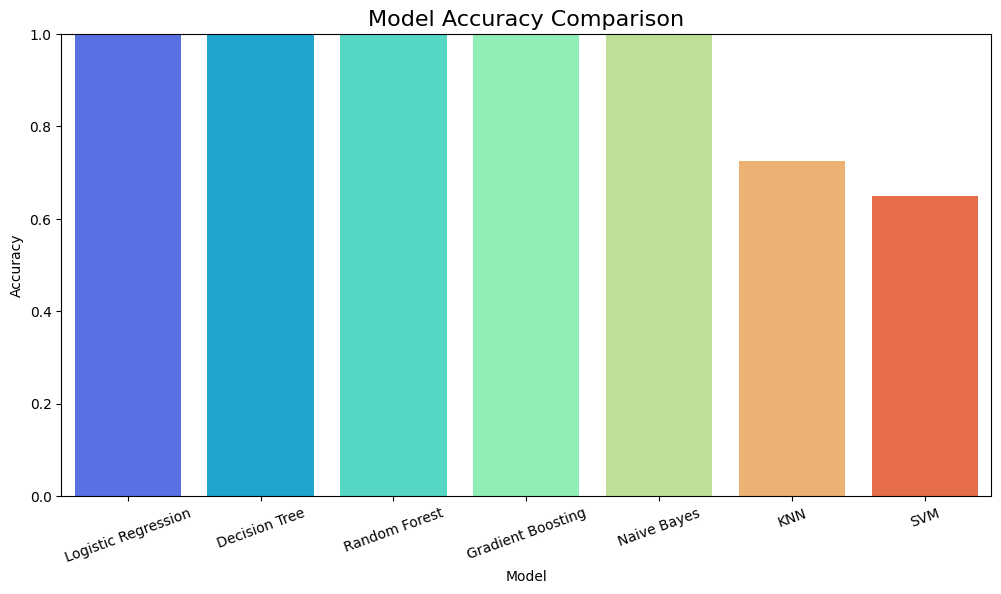

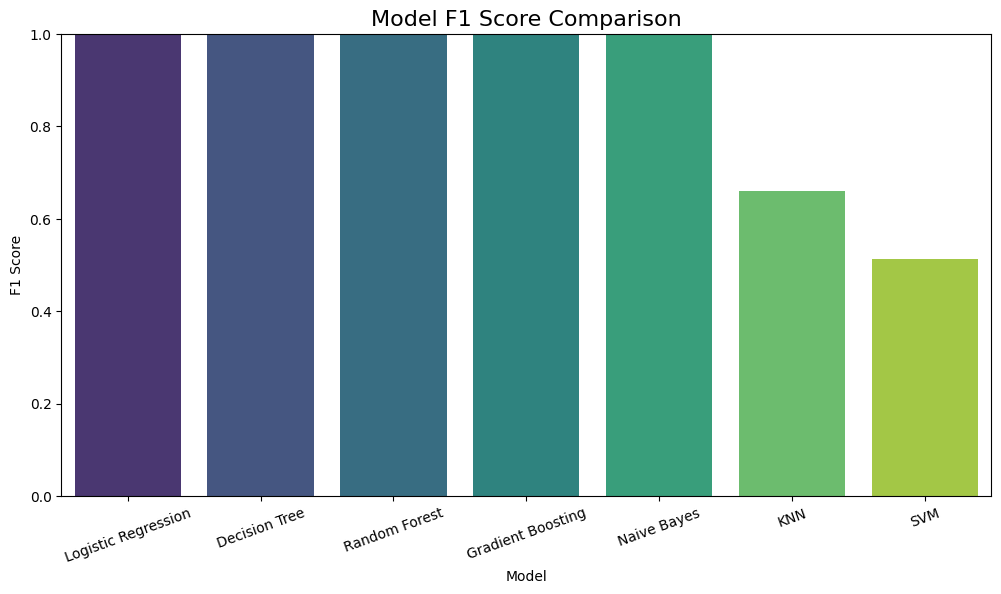


Top Important Features:

                  Feature  Importance
11     hallucination_span    0.241617
13        correction_text    0.214342
12    correct_information    0.191248
10     hallucination_type    0.108860
14               severity    0.084996
6           response_text    0.028945
23        response_length    0.021535
17  annotation_confidence    0.021120
4             prompt_text    0.017045
24          prompt_length    0.014498
8               task_type    0.009428
7                  domain    0.008099
3               prompt_id    0.004115
28                    day    0.003879
15            domain_risk    0.003663


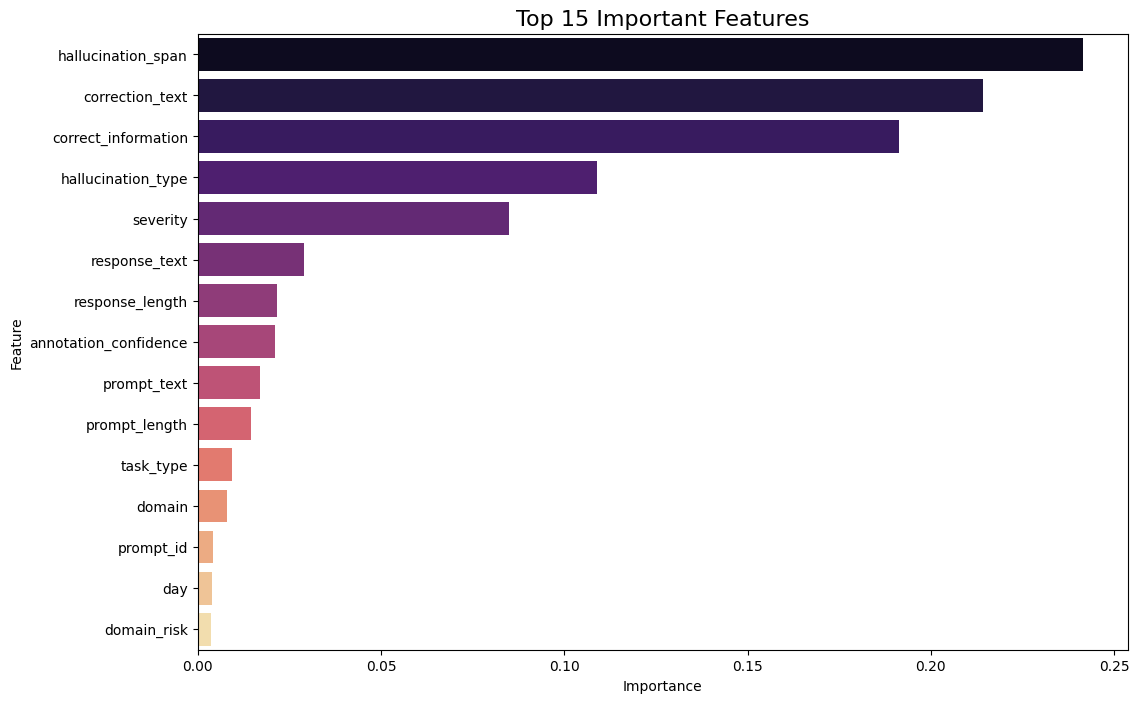


BEST MODEL

Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
ROC-AUC                      1.0
Name: 0, dtype: object

Dataset Saved Successfully!


In [15]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')



# ============================================================
# BASIC INFO
# ============================================================

print("Dataset Shape :", df.shape)

print("\nMissing Values Before Cleaning:\n")
print(df.isnull().sum())

# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Convert date column
df['created_date'] = pd.to_datetime(
    df['created_date'],
    errors='coerce'
)

# Extract features
df['year'] = df['created_date'].dt.year
df['month_created'] = df['created_date'].dt.month
df['day'] = df['created_date'].dt.day

# Drop original date
df.drop('created_date', axis=1, inplace=True)

# ============================================================
# TARGET VARIABLE
# ============================================================

target_column = 'hallucination_label'

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(columns=[target_column])

y = df[target_column]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nCategorical Columns :", len(categorical_cols))
print("Numerical Columns :", len(numerical_cols))

# ============================================================
# FIX OBJECT COLUMNS WITH FULL NaN
# ============================================================

for col in categorical_cols:

    # If entire column is NaN
    if X_train[col].isnull().all():

        X_train[col] = X_train[col].fillna("Unknown")
        X_test[col] = X_test[col].fillna("Unknown")

    else:

        mode_value = X_train[col].mode()[0]

        X_train[col] = X_train[col].fillna(mode_value)
        X_test[col] = X_test[col].fillna(mode_value)

# ============================================================
# FIX NUMERIC COLUMNS WITH FULL NaN
# ============================================================

for col in numerical_cols:

    # If entire column is NaN
    if X_train[col].isnull().all():

        X_train[col] = X_train[col].fillna(0)
        X_test[col] = X_test[col].fillna(0)

    else:

        median_value = X_train[col].median()

        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)

# ============================================================
# REMOVE REMAINING NaN
# ============================================================

X_train = X_train.fillna("Unknown")
X_test = X_test.fillna("Unknown")

# ============================================================
# VERIFY NaN REMOVED
# ============================================================

print("\nRemaining NaN in X_train :",
      X_train.isnull().sum().sum())

print("Remaining NaN in X_test :",
      X_test.isnull().sum().sum())

# ============================================================
# LABEL ENCODING
# ============================================================

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    # Convert to string
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    # Fit on train
    le.fit(X_train[col])

    # Add unseen labels
    unseen_labels = set(X_test[col]) - set(le.classes_)

    if unseen_labels:

        le.classes_ = np.append(
            le.classes_,
            list(unseen_labels)
        )

    # Transform
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

    label_encoders[col] = le

# ============================================================
# CONVERT EVERYTHING TO NUMERIC
# ============================================================

for col in X_train.columns:

    X_train[col] = pd.to_numeric(
        X_train[col],
        errors='coerce'
    )

    X_test[col] = pd.to_numeric(
        X_test[col],
        errors='coerce'
    )

# ============================================================
# FINAL NaN FIX
# ============================================================

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# ============================================================
# FINAL CHECK
# ============================================================

print("\nFINAL NaN COUNT")

print("X_train :", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

# ============================================================
# ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True)
}

# ============================================================
# TRAINING & EVALUATION
# ============================================================

results = []

plt.figure(figsize=(12,8))

for name, model in models.items():

    print("\n================================================")
    print("MODEL :", name)
    print("================================================")

    # ================= TRAIN =================

    model.fit(X_train, y_train)

    # ================= PREDICT =================

    y_pred = model.predict(X_test)

    # ================= METRICS =================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print("\nAccuracy :", round(accuracy,4))
    print("Precision :", round(precision,4))
    print("Recall :", round(recall,4))
    print("F1 Score :", round(f1,4))

    # ============================================================
    # CLASSIFICATION REPORT
    # ============================================================

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm'
    )

    plt.title(f'Confusion Matrix - {name}')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.ylabel("Actual")

    plt.show()

    # ============================================================
    # ROC CURVE
    # ============================================================

    if len(np.unique(y_train)) == 2:

        y_prob = model.predict_proba(X_test)[:,1]

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob
        )

        auc_score = roc_auc_score(
            y_test,
            y_prob
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'{name} AUC={auc_score:.2f}'
        )

    else:

        auc_score = np.nan

    # ============================================================
    # STORE RESULTS
    # ============================================================

    results.append({

        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': auc_score
    })

# ============================================================
# FINAL ROC CURVE
# ============================================================

if len(np.unique(y_train)) == 2:

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve Comparison")

    plt.legend()

    plt.show()

# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n================================================")
print("FINAL MODEL COMPARISON")
print("================================================\n")

print(results_df)

# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='rainbow'
)

plt.title("Model Accuracy Comparison", fontsize=16)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df,
    palette='viridis'
)

plt.title("Model F1 Score Comparison", fontsize=16)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({

    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:\n")

print(importance_df.head(15))

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15),
    palette='magma'
)

plt.title("Top 15 Important Features", fontsize=16)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n================================================")
print("BEST MODEL")
print("================================================\n")

print(best_model)

# ============================================================
# SAVE CLEAN DATASET
# ============================================================

final_dataset = X_train.copy()

final_dataset['target'] = y_train

final_dataset.to_csv(
    "cleaned_encoded_dataset.csv",
    index=False
)

print("\nDataset Saved Successfully!")

# ============================================================
# END OF FINAL PIPELINE
# ============================================================

## Thank you...pls upvote!!!!!!!!!!